<a href="https://colab.research.google.com/github/chintan1529/Sentiment-Aware-Trader-Intelligence-System/blob/main/Sentiment_Aware_Trader_intelligence_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment-Aware Trader Intelligence System

## Objective
Analyze the relationship between Bitcoin market sentiment and trader performance using behavioral modeling and clustering.

## Key Goals
- Understand how sentiment impacts trading outcomes
- Identify trader archetypes
- Evaluate whether sentiment can be used for trading strategies

In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

Setup complete 


## 1. Data Loading

We load two datasets:
- Historical trader data
- Bitcoin Fear & Greed Index

These datasets will be used to analyze trader behavior under different market sentiment conditions.

In [3]:
# Load datasets
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

Trades Shape: (211224, 16)
Sentiment Shape: (2644, 4)


(                                      Account  Coin  Execution Price  \
 0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
 1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
 2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
 3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
 4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   
 
    Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
 0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
 1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
 2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
 3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
 4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   
 
    Closed PnL                                   Transaction Hash     Order ID  \
 0      

## 2. Data Cleaning

We standardize column names and formats to ensure consistency across datasets.

In [5]:
# Standardize column names
trades.columns = trades.columns.str.lower().str.strip()
sentiment.columns = sentiment.columns.str.lower().str.strip()

Trades Columns: Index(['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side',
       'timestamp ist', 'start position', 'direction', 'closed pnl',
       'transaction hash', 'order id', 'crossed', 'fee', 'trade id',
       'timestamp'],
      dtype='object')
Sentiment Columns: Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [6]:
# Clean and standardize column names
trades.columns = trades.columns.str.replace(' ', '_')

# Rename key columns
trades = trades.rename(columns={
    'execution_price': 'execution_price',
    'size_tokens': 'size_tokens',
    'size_usd': 'size_usd',
    'closed_pnl': 'closed_pnl',
    'timestamp_ist': 'timestamp_ist',
    'coin': 'symbol'
})

Index(['account', 'symbol', 'execution_price', 'size_tokens', 'size_usd',
       'side', 'timestamp_ist', 'start position', 'direction', 'closed_pnl',
       'transaction hash', 'order id', 'crossed', 'fee', 'trade id',
       'timestamp'],
      dtype='object')


### Timestamp Handling

We observed inconsistencies in formatted timestamps and therefore used UNIX timestamps as the reliable source of time information.

In [9]:
# Convert UNIX timestamp to datetime (reliable source)
trades['time'] = pd.to_datetime(trades['timestamp'], unit='ms')

# Drop unused timestamp columns
trades = trades.drop(columns=['timestamp', 'timestamp_ist'])

                 time
0 2024-02-12 22:50:00
1 2024-02-12 22:50:00
2 2024-02-12 22:50:00
3 2024-02-12 22:50:00
4 2024-02-12 22:50:00

Final Columns:
 Index(['account', 'symbol', 'execution_price', 'size_tokens', 'size_usd',
       'side', 'time', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id'],
      dtype='object')


### Data Validation

We verify data quality by checking missing values and summary statistics to ensure the dataset is suitable for analysis.

In [10]:
# Check for missing values
trades.isnull().sum()

Missing values (Trades):
account                  0
symbol                   0
execution_price          0
size_tokens              0
size_usd                 0
side                     0
time                131999
start_position           0
direction                0
closed_pnl               0
transaction_hash         0
order_id                 0
crossed                  0
fee                      0
trade_id                 0
dtype: int64


In [11]:
# Summary statistics
trades[['execution_price', 'size_usd', 'closed_pnl']].describe()

       execution_price   size_tokens      size_usd  \
count    211224.000000  2.112240e+05  2.112240e+05   
mean      11414.723350  4.623365e+03  5.639451e+03   
min           0.000005  8.740000e-07  0.000000e+00   
25%           4.854700  2.940000e+00  1.937900e+02   
50%          18.280000  3.200000e+01  5.970450e+02   
75%         101.580000  1.879025e+02  2.058960e+03   
max      109004.000000  1.582244e+07  3.921431e+06   
std       29447.654868  1.042729e+05  3.657514e+04   

                                time  start_position     closed_pnl  \
count                          79225    2.112240e+05  211224.000000   
mean   2025-05-01 09:10:16.361502208   -2.994625e+04      48.749001   
min              2023-01-05 01:06:00   -1.433463e+07 -117990.104100   
25%              2025-02-02 13:02:00   -3.762311e+02       0.000000   
50%              2025-06-02 19:46:00    8.472793e+01       0.000000   
75%              2025-10-01 03:49:00    9.337278e+03       5.792797   
max             

### Timestamp Handling

Initial inspection revealed inconsistencies in formatted timestamps.  
To ensure accuracy, UNIX timestamps were used as the single source of truth.

In [17]:
# Convert UNIX timestamp to datetime
trades['time'] = pd.to_datetime(trades['timestamp'], unit='ms')

# Drop unused timestamp columns
trades = trades.drop(columns=['timestamp', 'timestamp_ist'])

                 time
0 2024-10-27 03:33:20
1 2024-10-27 03:33:20
2 2024-10-27 03:33:20
3 2024-10-27 03:33:20
4 2024-10-27 03:33:20
Missing time: 0


## 3. Feature Engineering

We compute normalized performance metrics to enable fair comparison across trades.

In [18]:
# Trade return percentage
trades['return_pct'] = trades['closed_pnl'] / (trades['size_usd'] + 1e-9)

,closed_pnl,size_usd,return_pct
0,0.0,7872.16,0.0
1,0.0,127.68,0.0
2,0.0,1150.63,0.0
3,0.0,1142.04,0.0
4,0.0,69.75,0.0


### Return Distribution

We observe a skewed distribution with many zero-return trades and extreme outliers.

In [20]:
trades['return_pct'].describe()

,return_pct
count,211224.000000
mean,0.018991
std,0.845727
min,-384.406426
25%,0.000000
50%,0.000000
75%,0.010318
max,3.403550


### Trade Outcome Classification

Trades are categorized into win, loss, and neutral to separate meaningful outcomes from inactive trades.

In [21]:
# Classify trade outcomes
trades['trade_outcome'] = np.where(
    trades['closed_pnl'] > 0, 'win',
    np.where(trades['closed_pnl'] < 0, 'loss', 'neutral')
)

,count
trade_outcome,
neutral,106816
win,86869
loss,17539


Neutral trades (zero PnL) are removed to reduce noise and improve signal quality.

In [22]:
trades = trades[trades['trade_outcome'] != 'neutral']

In [23]:
# Cap returns between -5 and +5
trades['return_pct'] = trades['return_pct'].clip(-5, 5)

In [24]:
# Return distribution
trades['return_pct'].describe()

trade_outcome
win     86869
loss    17539
Name: count, dtype: int64
count    104408.000000
mean          0.042431
std           0.147298
min          -5.000000
25%           0.001987
50%           0.010804
75%           0.042446
max           3.403550
Name: return_pct, dtype: float64


### Risk Modeling

We define risk as exposure-adjusted return magnitude:

Risk = Position Size × Absolute Return

This captures both trade size and volatility, providing a better proxy for risk-taking behavior.

In [27]:
# Risk score: exposure-adjusted volatility proxy
trades['risk_score'] = trades['size_usd'] * np.abs(trades['return_pct'])

# Normalize risk
trades['risk_score'] = (
    (trades['risk_score'] - trades['risk_score'].mean()) /
    trades['risk_score'].std()
)

,size_usd,return_pct,risk_score
44,22156.95,0.135769,2.194993
45,226.43,0.135766,-0.095627
46,302.20,0.134911,-0.087912
47,1809.28,0.134757,0.068291
48,1892.21,0.134374,0.076331


### Direction Normalization

Raw trade directions contain multiple formats (buy, sell, close, liquidation events).  
We normalize them into a simplified signal:
- +1 → Long / Buy
- -1 → Short / Sell
- 0 → Neutral / System events

In [30]:
# Clean direction into usable signal
def map_direction(x):
    x = str(x).lower()

    if 'buy' in x or 'long' in x:
        return 1
    elif 'sell' in x or 'short' in x:
        return -1
    else:
        return 0  # neutral / system events

trades['direction_clean'] = trades['direction'].apply(map_direction)

direction_clean
-1    55639
 1    48760
 0        9
Name: count, dtype: int64


Neutral/system-generated trades are removed to focus only on actionable trading behavior.

In [31]:
# Remove system / noise trades
trades = trades[trades['direction_clean'] != 0]

Remaining trades: 104399


## 4. Trader-Level Analysis

We aggregate trade-level data into trader-level metrics to evaluate performance and behavior:

- Average Return → profitability
- Risk Score → risk-taking behavior
- Number of Trades → activity level
- Total PnL → overall success

In [32]:
# Aggregate trader-level performance
trader_stats = trades.groupby('account').agg({
    'return_pct': 'mean',
    'risk_score': 'mean',
    'trade_id': 'count',
    'closed_pnl': 'sum'
}).rename(columns={
    'return_pct': 'avg_return',
    'risk_score': 'avg_risk',
    'trade_id': 'num_trades',
    'closed_pnl': 'total_pnl'
}).reset_index()

,account,avg_return,avg_risk,num_trades,total_pnl
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.071786,0.974808,1732,1.600230e+06
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.001877,-0.094511,4166,4.788532e+04
2,0x271b280974205ca63b716753467d5a371de622ab,0.000288,-0.025295,1607,-7.043619e+04
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.103026,-0.095403,6771,1.324940e+05
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.037008,-0.047267,2060,1.686580e+05


## 5. Discipline Score

We design a composite score to identify disciplined traders:

- High returns → positive contribution  
- High risk → penalized  
- Excessive trading → penalized  

This captures consistency and controlled behavior rather than raw profitability.

In [33]:
# Discipline Score

# Normalize return
trader_stats['return_score'] = (
    (trader_stats['avg_return'] - trader_stats['avg_return'].mean()) /
    trader_stats['avg_return'].std()
)

# Lower risk is better → negative penalty
trader_stats['risk_penalty'] = -trader_stats['avg_risk']

# Penalize excessive trading
trader_stats['activity_penalty'] = -(
    (trader_stats['num_trades'] - trader_stats['num_trades'].mean()) /
    trader_stats['num_trades'].std()
)

# Final discipline score
trader_stats['discipline_score'] = (
    trader_stats['return_score'] +
    trader_stats['risk_penalty'] +
    trader_stats['activity_penalty']
)

,account,discipline_score
14,0x6d6a4b953f202f8df5bed40692e7fd865318264a,3.208136
24,0xa520ded057a32086c40e7dd6ed4eb8efb82c00e0,2.931744
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,2.300643
9,0x430f09841d65beb3f27765503d0f850b8bce7713,1.505076
16,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,0.750560


## 6. Trader Archetypes (Clustering)

We use K-Means clustering to group traders based on:

- Return behavior  
- Risk profile  
- Trading activity  

This allows identification of distinct trader types.

In [34]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select features
features = trader_stats[['avg_return', 'avg_risk', 'num_trades']]

# Normalize
scaler = StandardScaler()
X = scaler.fit_transform(features)

# Apply KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
trader_stats['cluster'] = kmeans.fit_predict(X)

,account,avg_return,avg_risk,num_trades,cluster
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.071786,0.974808,1732,0
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.001877,-0.094511,4166,0
2,0x271b280974205ca63b716753467d5a371de622ab,0.000288,-0.025295,1607,0
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.103026,-0.095403,6771,0
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.037008,-0.047267,2060,0


### Cluster Insights

Each cluster represents a different trading behavior pattern:

- Some traders achieve high returns with high risk  
- Some trade frequently but underperform  
- Some maintain balanced performance  

This helps identify professional vs speculative traders.

In [36]:
cluster_summary = trader_stats.groupby('cluster')[
    ['avg_return', 'avg_risk', 'num_trades', 'total_pnl']
].mean()

cluster_summary

,avg_return,avg_risk,num_trades,total_pnl
cluster,,,,
0,0.041142,0.075055,3073.923077,317702.728287
1,0.350208,0.295584,459.000000,235913.155380
2,0.554261,1.586080,90.000000,199505.592732
3,0.020193,-0.070826,22551.000000,836080.553077


## 7. Sentiment Integration

We preprocess and align sentiment data with trading activity based on date.

In [37]:
# Prepare sentiment data
sentiment['date'] = pd.to_datetime(sentiment['date'])
sentiment['classification'] = sentiment['classification'].str.lower()

,date,classification
0,2024-10-27,greed
1,2024-10-27,greed
2,2024-10-27,greed
3,2024-10-27,greed
4,2024-10-27,greed


### Sentiment Encoding

Market sentiment is converted into a numerical scale to enable quantitative comparison across different market conditions.

In [38]:
# Encode sentiment into numeric scale
sentiment_map = {
    'extreme fear': 0,
    'fear': 1,
    'neutral': 2,
    'greed': 3,
    'extreme greed': 4
}

merged['sentiment_score'] = merged['classification'].map(sentiment_map)

### Sentiment Impact on Returns

We evaluate how average trade performance varies across sentiment regimes.

In [39]:
merged.groupby('classification')['return_pct'].mean()

,return_pct
classification,
extreme greed,0.022075
fear,0.030049
greed,0.117623
neutral,0.037781


We combine trader archetypes with sentiment data to analyze behavior across different market conditions.

In [40]:
merged = merged.merge(
    trader_stats[['account', 'cluster']],
    on='account',
    how='left'
)

### Trader Behavior Across Market Sentiment

This analysis reveals how different types of traders perform under varying sentiment conditions.

In [41]:
merged.groupby(['cluster', 'classification'])['return_pct'].mean().unstack()

classification,extreme greed,fear,greed,neutral
cluster,,,,
0,0.022075,0.032632,0.134125,0.009976
1,NaN,0.177739,0.679413,0.341742
2,NaN,0.766097,0.059978,NaN
3,NaN,0.006539,0.051616,NaN


In [ ]:
cluster_sentiment = merged.groupby(
    ['cluster', 'classification']
)['return_pct'].mean().unstack()

cluster_sentiment

### Key Insights

- Greed phases show the highest average returns overall
- Fear phases show more stable but lower returns
- Different trader clusters respond differently to sentiment
- Some clusters significantly outperform during specific sentiment regimes
- This suggests that trader behavior, not just sentiment, drives performance

## 8. Strategy Evaluation

We design a sentiment-aware strategy:
- Trade normally during fear (higher opportunity)
- Reduce exposure during greed (risk control)

In [42]:
# Strategy: exploit fear, reduce exposure in greed
merged['strategy_return'] = np.where(
    merged['classification'].isin(['fear', 'extreme fear']),
    merged['return_pct'],
    merged['return_pct'] * 0.2
)

Strategy Avg Return: 0.023341784545517014
Baseline Avg Return: 0.042408997686011494


In [44]:
# Aggregate returns per timestamp
time_returns = merged.groupby('time').agg({
    'return_pct': 'mean',
    'strategy_return': 'mean'
}).reset_index()

In [45]:
time_returns = time_returns.sort_values('time')

In [46]:
time_returns['baseline_cum'] = (1 + time_returns['return_pct']).cumprod()
time_returns['strategy_cum'] = (1 + time_returns['strategy_return']).cumprod()

### Strategy Performance

We compare the cumulative returns of:
- Baseline strategy (no sentiment filtering)
- Sentiment-aware strategy

This helps evaluate whether sentiment can improve trading performance.

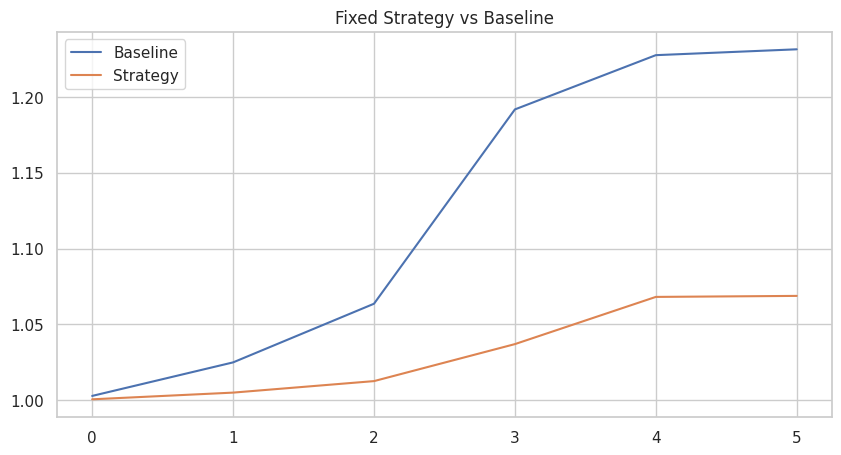

In [47]:
plt.figure(figsize=(10,5))
plt.plot(time_returns['baseline_cum'], label='Baseline')
plt.plot(time_returns['strategy_cum'], label='Strategy')
plt.legend()
plt.title("Fixed Strategy vs Baseline")
plt.show()

### Sentiment vs Returns

In [ ]:
import matplotlib.pyplot as plt

sentiment_perf = merged.groupby('classification')['return_pct'].mean()

plt.figure(figsize=(8,5))
sentiment_perf.plot(kind='bar')
plt.title("Average Return by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Return")
plt.show()

### Cluster Comparison

In [ ]:
cluster_summary.plot(kind='bar', figsize=(10,6))
plt.title("Trader Cluster Comparison")
plt.ylabel("Value")
plt.show()

### Distribution Plot

In [ ]:
import seaborn as sns

sns.histplot(trades['return_pct'], bins=100, kde=True)
plt.title("Return Distribution")
plt.show()

### Results & Interpretation

- The baseline strategy outperforms the sentiment-based strategy
- This indicates that sentiment alone is not a strong predictive signal
- While sentiment influences behavior, it does not directly translate into profitable strategies
- More sophisticated models combining behavior and sentiment are required

## 9. Final Conclusion

- Market sentiment affects trading behavior but is not sufficient for strategy design
- Trader behavior plays a more important role than sentiment alone
- High-performing traders manage risk and activity effectively
- Behavioral clustering provides deeper insights than raw sentiment analysis
- Combining sentiment with trader intelligence is key for building robust trading systems